In [ ]:
# installation imports
%pip install -U requests pandas numpy statsmodels matplotlib scipy

In [ ]:
# imports
import requests
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from scipy import stats


In [2]:
# Daten laden (inoffizielle API)
url = "https://api.kbstats.de/api/v1/players"
response = requests.get(url)
response.raise_for_status() # Fehler werfen, falls Request schiefgeht
players = response.json()
# In DataFrame umwandeln
df = pd.DataFrame(players)
# nur relevante Spalten auswählen
df = df[["name", "marketValue", "totalPoints", "averagePoints", "position", "trend"]]
# Daten bereinigen (nur Spieler mit sinnvollen Werten)
df = df.dropna(subset=["marketValue", "totalPoints"])
df = df[(df["marketValue"] > 0) & (df["totalPoints"] > 0)]
# Korrelation berechnen: Punkte vs. Marktwert
pearson_corr = df["totalPoints"].corr(df["marketValue"])
print(f"Pearson-Korrelation totalPoints ~ marketValue: {pearson_corr:.3f}")


Pearson-Korrelation totalPoints ~ marketValue: 0.902


                            OLS Regression Results                            
Dep. Variable:            marketValue   R-squared:                       0.813
Model:                            OLS   Adj. R-squared:                  0.813
Method:                 Least Squares   F-statistic:                     1746.
Date:                Sun, 11 Jan 2026   Prob (F-statistic):          3.49e-148
Time:                        12:59:57   Log-Likelihood:                -6731.3
No. Observations:                 403   AIC:                         1.347e+04
Df Residuals:                     401   BIC:                         1.347e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const       -1.951e+06    3.5e+05     -5.570      

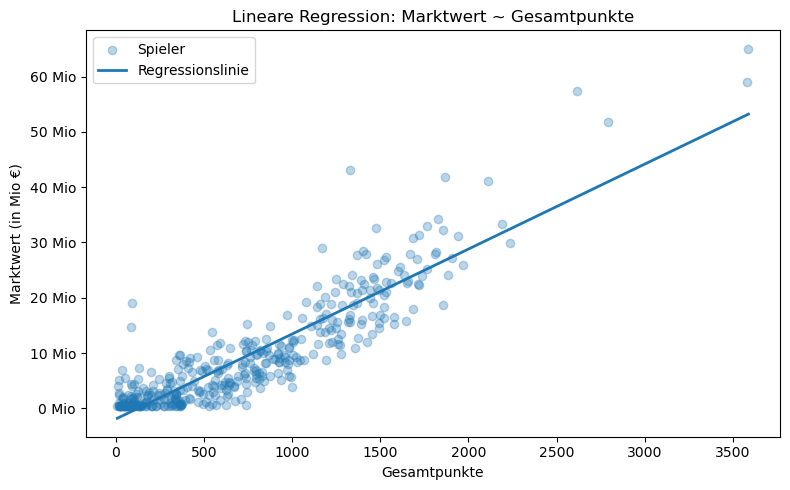

In [3]:
# Lineare Regression: Marktwert ~ Gesamtpunkte
X = df[["totalPoints"]]
X = sm.add_constant(X)
y = df["marketValue"]
model = sm.OLS(y, X).fit()
print(model.summary())
# Vorhersage-Linie für die Grafik berechnen
x_plot = np.linspace(df["totalPoints"].min(),
                     df["totalPoints"].max(),
                     100)
X_plot = sm.add_constant(x_plot)
y_plot = model.predict(X_plot)

# Formatter-Funktion um Millionen korrekt anzuzeigen
def format_mio(x, pos):
    return f"{x/1_000_000:.0f} Mio"
# Grafik erstellen
plt.figure(figsize=(8, 5))
plt.scatter(df["totalPoints"], y, alpha=0.3, label="Spieler")
plt.plot(x_plot, y_plot, linewidth=2, label="Regressionslinie")
ax = plt.gca()
ax.yaxis.set_major_formatter(FuncFormatter(format_mio)) 
plt.xlabel("Gesamtpunkte")
plt.ylabel("Marktwert (in Mio €)")
plt.title("Lineare Regression: Marktwert ~ Gesamtpunkte")
plt.legend()
plt.tight_layout()
plt.show()

                            OLS Regression Results                            
Dep. Variable:            marketValue   R-squared:                       0.839
Model:                            OLS   Adj. R-squared:                  0.836
Method:                 Least Squares   F-statistic:                     294.3
Date:                Sun, 11 Jan 2026   Prob (F-statistic):          2.13e-152
Time:                        13:01:14   Log-Likelihood:                -6701.2
No. Observations:                 403   AIC:                         1.342e+04
Df Residuals:                     395   BIC:                         1.345e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const         1.187e+05   2.14e+06      0.055   

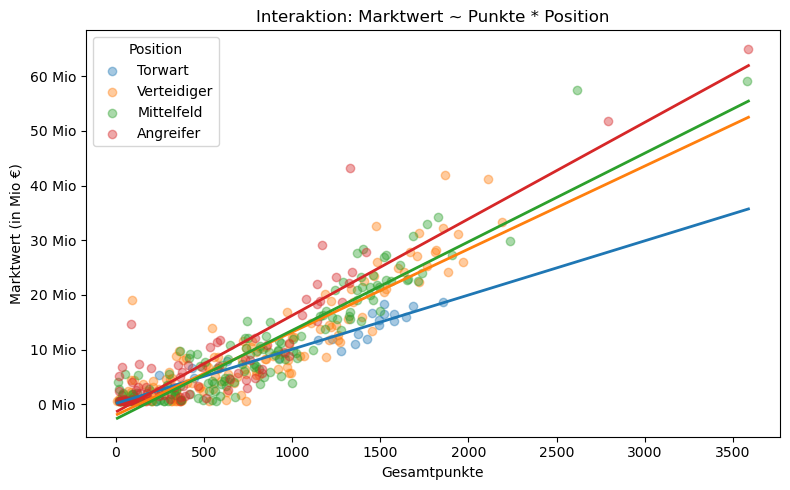

In [4]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Mapping Position → Label
pos_map = {1: "Torwart", 2: "Verteidiger", 3: "Mittelfeld", 4: "Angreifer"}
df["pos_label"] = df["position"].map(pos_map)

# Dummy-Variablen für Position (Referenzkategorie: Torwart)
df_dummies = pd.get_dummies(df["pos_label"], dtype=int)

# Wir verwenden Torwart als Referenz -> d.h. TW-Dummy nicht in X
df = pd.concat([df, df_dummies], axis=1)

# Interaktionstermen: Punkte * Position
df["Int_points_V"] = df["totalPoints"] * df["Verteidiger"]
df["Int_points_M"] = df["totalPoints"] * df["Mittelfeld"]
df["Int_points_A"] = df["totalPoints"] * df["Angreifer"]

# Modell: Marktwert ~ Punkte * Position
X = df[[
    "totalPoints",
    "Verteidiger", "Mittelfeld", "Angreifer",
    "Int_points_V", "Int_points_M", "Int_points_A"
]]
X = sm.add_constant(X)
y = df["marketValue"]

model = sm.OLS(y, X).fit()
print(model.summary())

# Farben je Position
pos_colors = {
    "Torwart":     "tab:blue",
    "Verteidiger": "tab:orange",
    "Mittelfeld":  "tab:green",
    "Angreifer":   "tab:red"
}

# Formatter-Funktion um Millionen korrekt anzuzeigen
def format_mio(x, pos):
    return f"{x/1_000_000:.0f} Mio"

fig, ax = plt.subplots(figsize=(8, 5))

# globaler Bereich für x
x_min = df["totalPoints"].min()
x_max = df["totalPoints"].max()
x_plot = np.linspace(x_min, x_max, 200)

# Für jede Position: Scatter + Regressionslinie aus dem *einen* Interaktionsmodell
for pos_label in ["Torwart", "Verteidiger", "Mittelfeld", "Angreifer"]:
    df_pos = df[df["pos_label"] == pos_label].copy()
    if df_pos.empty:
        continue

    # Scatterpunkte in Positionsfarbe
    ax.scatter(
        df_pos["totalPoints"],
        df_pos["marketValue"],
        alpha=0.4,
        color=pos_colors[pos_label],
        label=pos_label
    )

    # Design-Matrix für Vorhersage-Linie für diese Position bauen
    # Dummy-Werte entsprechend Position setzen
    if pos_label == "Torwart":
        V, M, A = 0, 0, 0
    elif pos_label == "Verteidiger":
        V, M, A = 1, 0, 0
    elif pos_label == "Mittelfeld":
        V, M, A = 0, 1, 0
    else:  # Angreifer
        V, M, A = 0, 0, 1

    pred_df = pd.DataFrame({
        "const":        1.0,
        "totalPoints":  x_plot,
        "Verteidiger":  V,
        "Mittelfeld":   M,
        "Angreifer":    A,
        "Int_points_V": x_plot * V,
        "Int_points_M": x_plot * M,
        "Int_points_A": x_plot * A
    })

    y_plot = model.predict(pred_df)

    # Regressionslinie zeichnen
    ax.plot(
        x_plot,
        y_plot,
        color=pos_colors[pos_label],
        linewidth=2
    )

# Achsen / Titel
ax.yaxis.set_major_formatter(FuncFormatter(format_mio))
ax.set_xlabel("Gesamtpunkte")
ax.set_ylabel("Marktwert (in Mio €)")
ax.set_title("Interaktion: Marktwert ~ Punkte * Position")
ax.legend(title="Position")
plt.tight_layout()
plt.show()



--- Verteilung: marketValue ---
n = 403
Mittelwert = 9545462.77
Median     = 6568450.00
Std        = 10060973.93
Skewness   = 1.863
Kurtosis   = 5.018
Shapiro-Wilk p (Stichprobe) = 3.957e-21


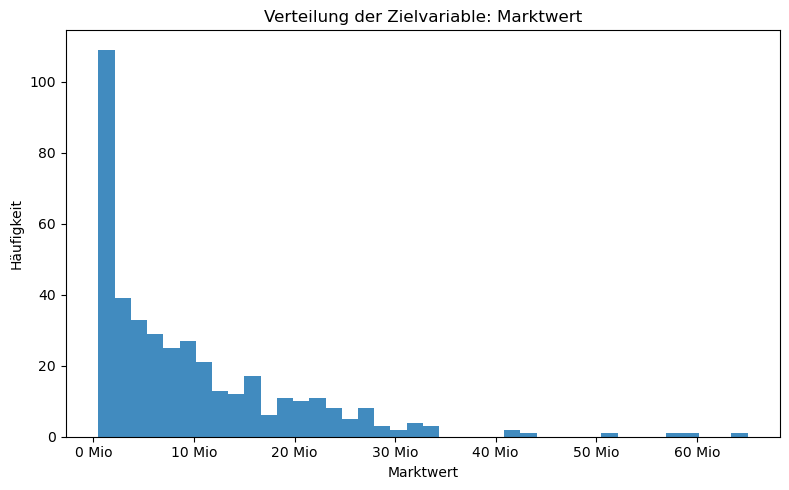

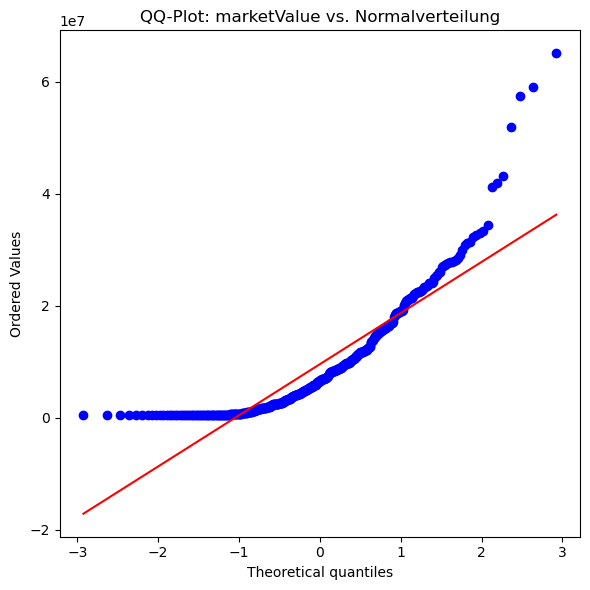


--- Verteilung: logMarketValue ---
n = 403
Mittelwert = 15.39
Median     = 15.70
Std        = 1.33
Skewness   = -0.413
Kurtosis   = -0.978
Shapiro-Wilk p (Stichprobe) = 7.483e-13


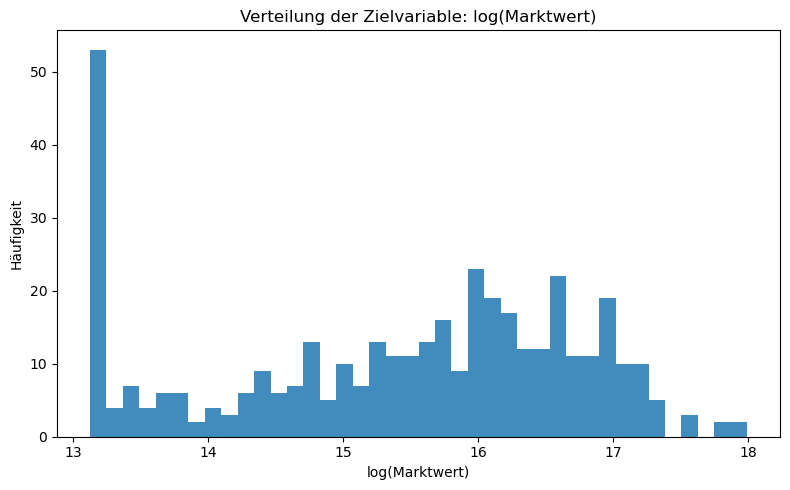

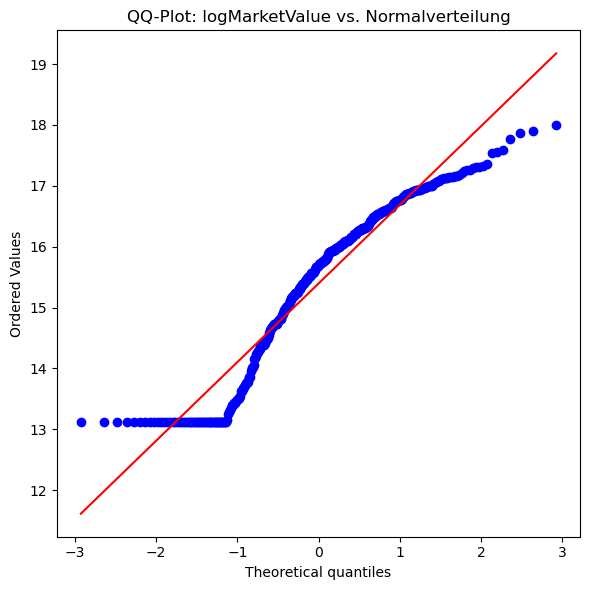


--- Häufigkeiten: position ---
position
1     23
2    149
3    150
4     81
Name: count, dtype: int64


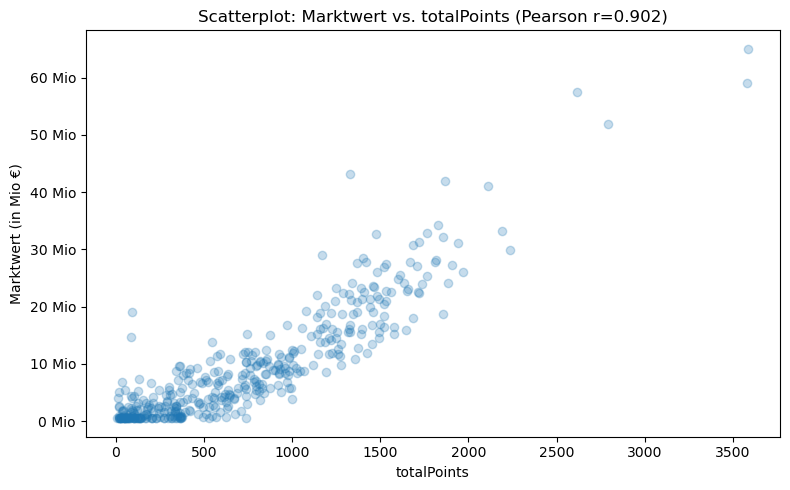

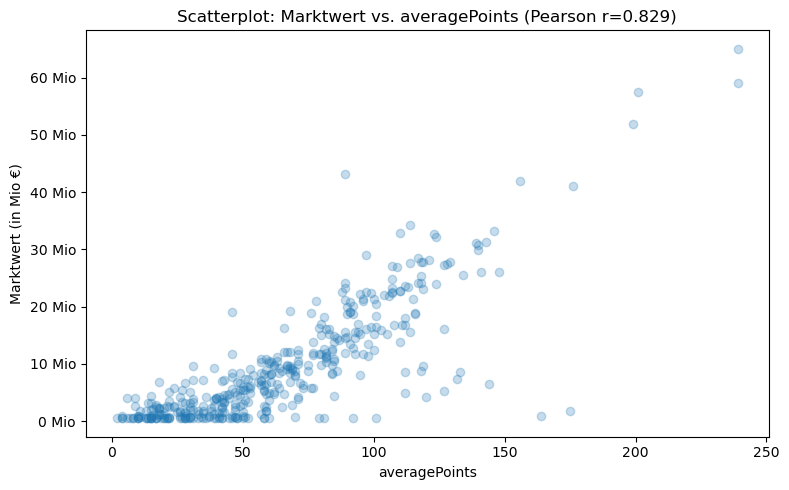

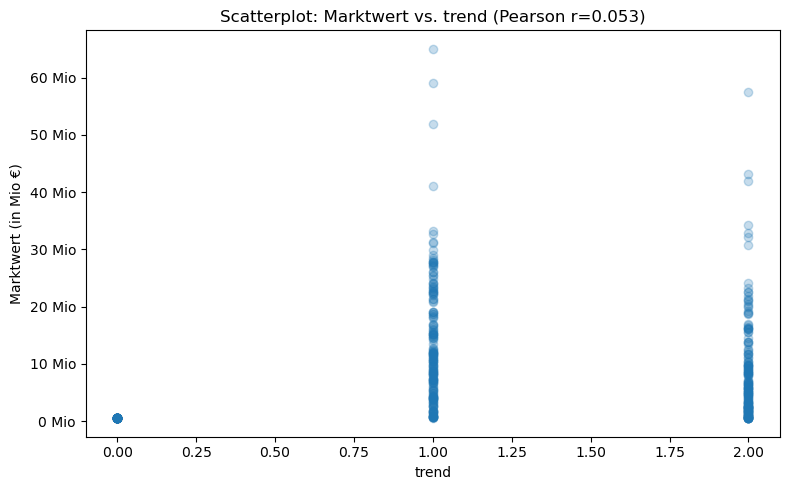

C:\Users\a380a\AppData\Local\Temp\ipykernel_9588\1650865369.py:110: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=cats, showfliers=False)


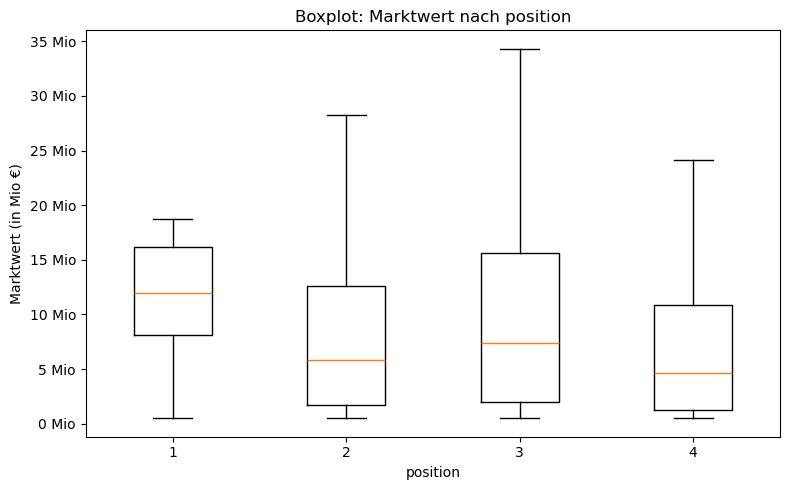

In [ ]:
target = "marketValue"

# Welche Spalten sind numerische Prädiktoren?
numeric_predictors = [c for c in ["totalPoints", "averagePoints", "games", "trend", "pointsPerValue"]
                      if c in df.columns]

# Welche Spalten sind kategorial/binary Prädiktoren?
categorical_predictors = [c for c in ["position", "status"]
                          if c in df.columns]

# Clean: nur sinnvolle Zielwerte
df = df.dropna(subset=[target]).copy()
df = df[df[target] > 0]

# Optional: log-Target für bessere „Normalität“
df["logMarketValue"] = np.log(df[target])

def format_mio(x, pos):
    return f"{x/1_000_000:.0f} Mio"



# Verteilung der Zielvariable
def describe_distribution(series, name):
    s = series.dropna()
    print(f"\n--- Verteilung: {name} ---")
    print(f"n = {len(s)}")
    print(f"Mittelwert = {s.mean():.2f}")
    print(f"Median     = {s.median():.2f}")
    print(f"Std        = {s.std():.2f}")
    print(f"Skewness   = {stats.skew(s):.3f}")
    print(f"Kurtosis   = {stats.kurtosis(s):.3f}")

    # Stichprobe ziehen (max. 5000) für Shapiro.
    sample = s.sample(min(5000, len(s)), random_state=42)
    shapiro_p = stats.shapiro(sample)[1]
    print(f"Shapiro-Wilk p (Stichprobe) = {shapiro_p:.4g}")

# Histogramm + QQ-Plot (jeweils eigenes Figure)
def plot_hist(series, title, xlabel, mio_axis=False):
    plt.figure(figsize=(8,5))
    plt.hist(series.dropna(), bins=40, alpha=0.85)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Häufigkeit")
    if mio_axis:
        plt.gca().xaxis.set_major_formatter(FuncFormatter(format_mio))
    plt.tight_layout()
    plt.show()

def plot_qq(series, title):
    plt.figure(figsize=(6,6))
    stats.probplot(series.dropna(), dist="norm", plot=plt)
    plt.title(title)
    plt.tight_layout()
    plt.show()

# Zielvariable: marketValue
describe_distribution(df[target], "marketValue")
plot_hist(df[target], "Verteilung der Zielvariable: Marktwert", "Marktwert", mio_axis=True)
plot_qq(df[target], "QQ-Plot: marketValue vs. Normalverteilung")

# Zielvariable: log(MarketValue)
describe_distribution(df["logMarketValue"], "logMarketValue")
plot_hist(df["logMarketValue"], "Verteilung der Zielvariable: log(Marktwert)", "log(Marktwert)")
plot_qq(df["logMarketValue"], "QQ-Plot: logMarketValue vs. Normalverteilung")

# Häufigkeiten kategorialer Variablen
for col in categorical_predictors:
    print(f"\n--- Häufigkeiten: {col} ---")
    print(df[col].value_counts(dropna=False).sort_index())


# Zusammenhang je Prädiktor mit Zielvariable

# Numerisch -> Scatterplot + Pearson-Korrelation
for col in numeric_predictors:
    tmp = df.dropna(subset=[col, target])
    if len(tmp) < 5:
        continue

    r = tmp[col].corr(tmp[target])  # Pearson
    plt.figure(figsize=(8,5))
    plt.scatter(tmp[col], tmp[target], alpha=0.25)
    plt.gca().yaxis.set_major_formatter(FuncFormatter(format_mio))
    plt.xlabel(col)
    plt.ylabel("Marktwert (in Mio €)")
    plt.title(f"Scatterplot: Marktwert vs. {col} (Pearson r={r:.3f})")
    plt.tight_layout()
    plt.show()


# Kategorial -> Boxplot (Marktwert nach Kategorie)
for col in categorical_predictors:
    tmp = df.dropna(subset=[col, target]).copy()
    if tmp[col].nunique() < 2:
        continue

    # Sortiere Kategorien (bei position numerisch sinnvoll)
    cats = sorted(tmp[col].unique())

    data = [tmp[tmp[col] == cat][target].values for cat in cats]

    plt.figure(figsize=(8,5))
    plt.boxplot(data, labels=cats, showfliers=False)
    plt.gca().yaxis.set_major_formatter(FuncFormatter(format_mio))
    plt.xlabel(col)
    plt.ylabel("Marktwert (in Mio €)")
    plt.title(f"Boxplot: Marktwert nach {col}")
    plt.tight_layout()
    plt.show()


In [6]:
pos_map = {1:"Torwart", 2:"Verteidiger", 3:"Mittelfeld", 4:"Angreifer"}

counts = df["position"].value_counts().sort_index()
print(counts.rename(index=pos_map))          # absolute Häufigkeit


position
Torwart         23
Verteidiger    149
Mittelfeld     150
Angreifer       81
Name: count, dtype: int64
